# Imports & paths

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("LOKY_MAX_CPU_COUNT", os.environ.get("NUMBER_OF_PROCESSORS", "1"))

def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src" / "cnt_project").exists():
            return p
    raise RuntimeError("Could not locate project root containing src/cnt_project")

PROJECT_ROOT = _find_project_root(Path.cwd())

PROJECT_SRC_ROOT = PROJECT_ROOT / "src"
NOTEBOOK_ROOT = PROJECT_ROOT / "notebooks" / "paper_figures"

for p in [str(PROJECT_SRC_ROOT), str(NOTEBOOK_ROOT)]:
    if p in sys.path:
        sys.path.remove(p)

# Main project package: cnt_project.*
sys.path.insert(0, str(PROJECT_SRC_ROOT))

# Current notebook helper package: src.*
sys.path.insert(0, str(NOTEBOOK_ROOT))

import json
import pandas as pd
import numpy as np
from scipy.ndimage import distance_transform_edt
from skimage.draw import polygon2mask
from skimage.morphology import skeletonize

from src.utils.paths import (
    NERWER_MODEL_DIRS,
    MODEL_OUTPUTS_ROOT,
    OUTPUTS,
    GT_TEST_ANNOTATIONS_PATH,
)
from src.utils.constants import MICRONS_PER_PIXEL
from cnt_project.features.core.polygon_geometry_paper_figures import (
    extract_polygon_geometry_stats_from_pred,
    )
from cnt_project.features.core.cnt_feature_extraction import (
    calculate_cnt_features_from_annotations,
)

from cnt_project.visualizations.experiments.paper_figures.correlation_plots import (
    precision_vs_width,
    noise_vs_width,
    precision_vs_noise,
)

from cnt_project.io.paths import ProjectPaths

import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science", "no-latex"])

P = ProjectPaths.from_here(PROJECT_ROOT / "src" / "cnt_project" / "io" / "paths.py")

print(f"Using MODEL_OUTPUTS_ROOT: {MODEL_OUTPUTS_ROOT}")

Using MODEL_OUTPUTS_ROOT: C:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs


# Define Inputs

In [2]:
MODEL_NAME = "Nanovision"   

model_inference_dir = NERWER_MODEL_DIRS[MODEL_NAME]
model_run_dir = model_inference_dir.parent

# Predicted polygons JSON location (new structure: global_outputs/runs/<RUN>/inference/...)
PRED_JSON = model_inference_dir / "predicted_annotations_poly.json"

# Metrics file location in new structure can vary by pipeline; prefer canonical files.
metrics_candidates = [
    model_run_dir / "per_image_threshold_metrics.csv",
    model_run_dir / "eval" / "micro_eval" / "per_image_threshold_metrics.csv",
    model_run_dir / "eval" / "dsb" / "Diagnostic_eval__gt-chain_none__pred-poly" / "dsb_per_image_threshold_metrics.csv",
    model_run_dir / "eval" / "dsb" / "Diagnostic_eval__gt-old__pred-poly" / "dsb_per_image_threshold_metrics.csv",
    model_run_dir / "eval" / "dsb" / "Diagnostic_eval" / "dsb_per_image_threshold_metrics.csv",
]
METRICS_FILE = next((p for p in metrics_candidates if p.exists()), metrics_candidates[0])

# Noise CSV (canonical location from ProjectPaths metadata for test split).
NOISE_CSV = P.metadata_file("test", "noise_evaluation_with_classes.csv")

# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------
SAVE_DIR = OUTPUTS.setdefault("precision_width", OUTPUTS["scoring"].parent / "precision_width")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

SAVE_PATH = SAVE_DIR / "precision_vs_width_nanovision"

print(f"PRED_JSON: {PRED_JSON}")
print(f"METRICS_FILE: {METRICS_FILE}")
print(f"NOISE_CSV: {NOISE_CSV}")
SAVE_PATH

PRED_JSON: C:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs\fluo_edt_edt_score_symmetry_score_without_smoothing_20260610_1004\inference\predicted_annotations_poly.json
METRICS_FILE: C:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs\fluo_edt_edt_score_symmetry_score_without_smoothing_20260610_1004\eval\dsb\Diagnostic_eval__gt-chain_none__pred-poly\dsb_per_image_threshold_metrics.csv
NOISE_CSV: C:\Users\abd93000\PycharmProjects\cnt_project_v2\data\annotations_uniques\test\metadata\noise_evaluation_with_classes.csv


WindowsPath('C:/Users/abd93000/PycharmProjects/cnt_project_v2/notebooks/paper_figures/outputs/precision_width/precision_vs_width_nanovision')

# Load Noise Values

In [3]:
noise_df = pd.read_csv(NOISE_CSV)

print("Noise CSV columns:", noise_df.columns.tolist())

# Normalize image_id to lower-case (important for merging)
noise_df["image_id"] = noise_df["image_id"].str.split(".").str[0].str.lower()

# Prefer existing class labels from the noise CSV.
if "Noise_KMeans" in noise_df.columns:
    _raw_noise_class = noise_df["Noise_KMeans"].astype(str).str.strip().str.lower()
    print("Using Noise_KMeans as noise class column.")
elif "Noise_Otsu" in noise_df.columns:
    _raw_noise_class = noise_df["Noise_Otsu"].astype(str).str.strip().str.lower()
    print("Using Noise_Otsu as noise class column.")
elif "noise_class" in noise_df.columns:
    _raw_noise_class = noise_df["noise_class"].astype(str).str.strip().str.lower()
    print("Using noise_class as noise class column.")
elif "noise_group" in noise_df.columns:
    _raw_noise_class = noise_df["noise_group"].astype(str).str.strip().str.lower()
    print("Using noise_group as noise class column.")
else:
    _raw_noise_class = pd.Series(index=noise_df.index, dtype="object")
    print("No noise class column found. Will use median split fallback.")

noise_df["noise_group"] = np.where(
    _raw_noise_class.str.contains("low|clean", na=False),
    "Clean",
    np.where(
        _raw_noise_class.str.contains("high|noisy", na=False),
        "Noisy",
        np.nan,
    ),
)

# Fallback: median split on noise_std when no usable class label is present.
if noise_df["noise_group"].isna().all():
    noise_median = float(noise_df["noise_std"].median())
    noise_df["noise_group"] = np.where(
        noise_df["noise_std"] <= noise_median,
        "Clean",
        "Noisy",
    )
    print(f"Derived noise_group via median split at noise_std={noise_median:.6f}")

# Keep only the relevant columns.
noise_df = noise_df[["image_id", "noise_std", "noise_group"]]

display(noise_df.head(35))
print(noise_df["noise_group"].value_counts(dropna=False))

Noise CSV columns: ['image_id', 'noise_std', 'Noise_Otsu', 'Noise_KMeans']
Using Noise_KMeans as noise class column.


,image_id,noise_std,noise_group
0,1293-22_3_2_20230306222551,28.169017,Noisy
1,400-1093-w11-c1p1-befo3-10sp-15flow_left,5.189029,Clean
2,400-1093-w11-c1p2-befo3-20sp-15flow_left,6.671608,Clean
3,400-1093-w13-c1-p1-10sp-15flow_left,6.671611,Clean
4,400-1093-w16-c-1-p1-10sp-15flow_left,8.154188,Clean
5,400-1093-w17-c1p3-20sp-03flow_right,9.636768,Clean
6,400-1293-17-c10k1r5_pd_sp0_9_fl0_1_right,17.790959,Noisy
7,400-1293-17-c3k1r5_pd_sp0_3_fl0_1_left,10.378054,Clean
8,400-1293-17-c3k1r5_pd_sp0_3_fl0_1_right,10.378053,Clean
9,400-1293-17-c79k1r5_pd_sp0_6_fl0_1_right,22.238694,Noisy


noise_group
Clean    20
Noisy    10
Name: count, dtype: int64


## Audit

In [4]:
print("NOISE_CSV:", NOISE_CSV)
print("Exists:", NOISE_CSV.exists())

noise_raw = pd.read_csv(NOISE_CSV)
print(noise_raw.columns.tolist())
print("Noise rows:", len(noise_raw))
print("Unique image ids:", noise_raw["image_id"].str.split(".").str[0].str.lower().nunique())
display(noise_raw.head())
display(noise_raw["noise_std"].describe())

NOISE_CSV: C:\Users\abd93000\PycharmProjects\cnt_project_v2\data\annotations_uniques\test\metadata\noise_evaluation_with_classes.csv
Exists: True
['image_id', 'noise_std', 'Noise_Otsu', 'Noise_KMeans']
Noise rows: 30
Unique image ids: 30


,image_id,noise_std,Noise_Otsu,Noise_KMeans
0,1293-22_3_2_20230306222551.tif,28.169017,Noisy,Noisy
1,400-1093-w11-c1p1-befo3-10sp-15flow_left.tif,5.189029,Clean,Clean
2,400-1093-w11-c1p2-befo3-20sp-15flow_left.tif,6.671608,Clean,Clean
3,400-1093-w13-c1-p1-10sp-15flow_left.tif,6.671611,Clean,Clean
4,400-1093-w16-c-1-p1-10sp-15flow_left.tif,8.154188,Clean,Clean


count    30.000000
mean     12.676056
std       6.398620
min       3.706453
25%       8.154182
50%      11.119343
75%      17.049664
max      28.169017
Name: noise_std, dtype: float64

# Load Metrics (Precision per Image)

In [5]:
metrics_df = pd.read_csv(METRICS_FILE)
metrics_df["image_id"] = metrics_df["image_id"].str.split(".").str[0].str.lower()

metrics_df = metrics_df[metrics_df["IoU_thresh"] == 0.05].copy()
metrics_df = metrics_df[["image_id", "TP", "FP", "FN", "precision"]]

den = (2.0 * metrics_df["TP"]) + metrics_df["FP"] + metrics_df["FN"]
metrics_df["f1_005"] = np.where(den > 0.0, (2.0 * metrics_df["TP"]) / den, np.nan)

metrics_df.head(35)

,image_id,TP,FP,FN,precision,f1_005
0,1293-22_3_2_20230306222551,97,58,7,0.625806,0.749035
10,400-1093-w11-c1p1-befo3-10sp-15flow_left,147,28,16,0.840000,0.869822
20,400-1093-w11-c1p2-befo3-20sp-15flow_left,218,57,23,0.792727,0.844961
30,400-1093-w13-c1-p1-10sp-15flow_left,119,11,12,0.915385,0.911877
40,400-1093-w16-c-1-p1-10sp-15flow_left,205,76,14,0.729537,0.820000
50,400-1093-w17-c1p3-20sp-03flow_right,290,190,19,0.604167,0.735108
60,400-1293-17-c10k1r5_pd_sp0_9_fl0_1_right,4,2,0,0.666667,0.800000
70,400-1293-17-c3k1r5_pd_sp0_3_fl0_1_left,16,2,1,0.888889,0.914286
80,400-1293-17-c3k1r5_pd_sp0_3_fl0_1_right,11,0,0,1.000000,1.000000
90,400-1293-17-c79k1r5_pd_sp0_6_fl0_1_right,7,0,0,1.000000,1.000000


# Load DSB Metrics

In [6]:
DSB_METRICS_FILE = (
    model_run_dir
    / "eval"
    / "dsb"
    / "Diagnostic_eval__gt-chain_none__pred-poly"
    / "dsb_per_image_threshold_metrics.csv"
)

print("DSB_METRICS_FILE:", DSB_METRICS_FILE)
print("Exists:", DSB_METRICS_FILE.exists())

dsb_raw = pd.read_csv(DSB_METRICS_FILE)
dsb_raw["image_id"] = dsb_raw["image_id"].str.split(".").str[0].str.lower()

print(dsb_raw.columns.tolist())
display(dsb_raw.head(500))

DSB_METRICS_FILE: C:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs\fluo_edt_edt_score_symmetry_score_without_smoothing_20260610_1004\eval\dsb\Diagnostic_eval__gt-chain_none__pred-poly\dsb_per_image_threshold_metrics.csv
Exists: True
['image_id', 'IoU_thresh', 'TP', 'FP', 'FN', 'num_gt_objects', 'num_pred_objects', 'avg_dice', 'dsb_precision', 'precision', 'recall', 'f1_score', 'fdr']


,image_id,IoU_thresh,TP,FP,FN,num_gt_objects,num_pred_objects,avg_dice,dsb_precision,precision,recall,f1_score,fdr
0,1293-22_3_2_20230306222551,0.05,97,58,7,104,155,0.529024,0.598765,0.625806,0.932692,0.749035,0.374194
1,1293-22_3_2_20230306222551,0.15,95,60,9,104,155,0.529024,0.579268,0.612903,0.913462,0.733591,0.387097
2,1293-22_3_2_20230306222551,0.25,79,76,25,104,155,0.529024,0.438889,0.509677,0.759615,0.610039,0.490323
3,1293-22_3_2_20230306222551,0.35,62,93,42,104,155,0.529024,0.314721,0.400000,0.596154,0.478764,0.600000
4,1293-22_3_2_20230306222551,0.45,39,116,65,104,155,0.529024,0.177273,0.251613,0.375000,0.301158,0.748387
...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,400-1605-w8_map_00049_top_right,0.55,4,65,54,58,69,0.465886,0.032520,0.057971,0.068966,0.062992,0.942029
296,400-1605-w8_map_00049_top_right,0.65,1,68,57,58,69,0.465886,0.007937,0.014493,0.017241,0.015748,0.985507
297,400-1605-w8_map_00049_top_right,0.75,0,69,58,58,69,0.465886,0.000000,0.000000,0.000000,0.000000,1.000000
298,400-1605-w8_map_00049_top_right,0.85,0,69,58,58,69,0.465886,0.000000,0.000000,0.000000,0.000000,1.000000


In [7]:
print(dsb_raw["IoU_thresh"].value_counts().sort_index())

IoU_thresh
0.05    30
0.15    30
0.25    30
0.35    30
0.45    30
0.55    30
0.65    30
0.75    30
0.85    30
0.95    30
Name: count, dtype: int64


# Extract DSB AP@0.05 and DSB mAP

In [8]:
dsb_ap_005_df = (
    dsb_raw[dsb_raw["IoU_thresh"] == 0.05]
    [["image_id", "dsb_precision"]]
    .rename(columns={"dsb_precision": "dsb_ap_005"})
    .copy()
)

# DSB mAP across all IoU thresholds per image
dsb_map_df = (
    dsb_raw
    .groupby("image_id", as_index=False)["dsb_precision"]
    .mean()
    .rename(columns={"dsb_precision": "dsb_map"})
)

dsb_metrics_df = (
    dsb_ap_005_df
    .merge(dsb_map_df, on="image_id", how="outer")
)

display(dsb_metrics_df.head(35))
print("DSB metric images:", dsb_metrics_df["image_id"].nunique())

,image_id,dsb_ap_005,dsb_map
0,1293-22_3_2_20230306222551,0.598765,0.222377
1,400-1093-w11-c1p1-befo3-10sp-15flow_left,0.769634,0.337610
2,400-1093-w11-c1p2-befo3-20sp-15flow_left,0.731544,0.298086
3,400-1093-w13-c1-p1-10sp-15flow_left,0.838028,0.400042
4,400-1093-w16-c-1-p1-10sp-15flow_left,0.694915,0.296122
5,400-1093-w17-c1p3-20sp-03flow_right,0.581162,0.200587
6,400-1293-17-c10k1r5_pd_sp0_9_fl0_1_right,0.666667,0.277778
7,400-1293-17-c3k1r5_pd_sp0_3_fl0_1_left,0.842105,0.486231
8,400-1293-17-c3k1r5_pd_sp0_3_fl0_1_right,1.000000,0.556190
9,400-1293-17-c79k1r5_pd_sp0_6_fl0_1_right,1.000000,0.608333


DSB metric images: 30


In [9]:
check_dsb = (
    dsb_raw[dsb_raw["IoU_thresh"] == 0.05]
    [["image_id", "precision", "dsb_precision"]]
    .copy()
)

check_dsb["diff_classical_minus_dsb"] = (
    check_dsb["precision"] - check_dsb["dsb_precision"]
)

display(check_dsb.head(35))
print(check_dsb["diff_classical_minus_dsb"].describe())

,image_id,precision,dsb_precision,diff_classical_minus_dsb
0,1293-22_3_2_20230306222551,0.625806,0.598765,0.027041
10,400-1093-w11-c1p1-befo3-10sp-15flow_left,0.840000,0.769634,0.070366
20,400-1093-w11-c1p2-befo3-20sp-15flow_left,0.792727,0.731544,0.061184
30,400-1093-w13-c1-p1-10sp-15flow_left,0.915385,0.838028,0.077356
40,400-1093-w16-c-1-p1-10sp-15flow_left,0.729537,0.694915,0.034622
50,400-1093-w17-c1p3-20sp-03flow_right,0.604167,0.581162,0.023004
60,400-1293-17-c10k1r5_pd_sp0_9_fl0_1_right,0.666667,0.666667,0.000000
70,400-1293-17-c3k1r5_pd_sp0_3_fl0_1_left,0.888889,0.842105,0.046784
80,400-1293-17-c3k1r5_pd_sp0_3_fl0_1_right,1.000000,1.000000,0.000000
90,400-1293-17-c79k1r5_pd_sp0_6_fl0_1_right,1.000000,1.000000,0.000000


count    30.000000
mean      0.044039
std       0.032341
min       0.000000
25%       0.021399
50%       0.040249
75%       0.066354
max       0.133102
Name: diff_classical_minus_dsb, dtype: float64


# Extract Polygon Geometry (mean width per image)

In [11]:
import json

with open(PRED_JSON, "r") as f:
    pred_coco = json.load(f)

# Compute polygon properties per image using your existing function
stats_list = []

# Build ID → filename mapping
id_to_file = {im["id"]: im["file_name"] for im in pred_coco["images"]}

# Group annotations by image
anns_by_image = {}
for ann in pred_coco["annotations"]:
    anns_by_image.setdefault(ann["image_id"], []).append(ann)

for img_id, anns in anns_by_image.items():
    props = calculate_cnt_features_from_annotations(
        anns, 256, 256,
    )
    if "num_polygons" not in props or props["num_polygons"] == 0:
        continue

    stats_list.append({
        "image_id": id_to_file[img_id].split(".")[0].lower(),
        "mean_width_px": props.get("average_width", 0.0),
        "mean_length_px": props.get("average_length", 0.0),
        "n_objects": props["num_polygons"]
    })

# this was the original used function for this plot estimate width as min rotated rectangke 
# if you want the new width use calculate_polygon_properties_from_json instead
stats_df = extract_polygon_geometry_stats_from_pred(PRED_JSON)
stats_df.head(35)

,image_id,mean_width_px,mean_length_px,n_objects
0,1293-22_3_2_20230306222551,3.764149,25.264964,155
1,400-1093-w11-c1p1-befo3-10sp-15flow_left,5.320415,29.761275,175
2,400-1093-w11-c1p2-befo3-20sp-15flow_left,5.095643,26.979749,275
3,400-1093-w13-c1-p1-10sp-15flow_left,5.314571,26.105626,130
4,400-1093-w16-c-1-p1-10sp-15flow_left,5.348524,25.076475,281
5,400-1093-w17-c1p3-20sp-03flow_right,4.880074,20.938969,480
6,400-1293-17-c10k1r5_pd_sp0_9_fl0_1_right,6.917447,34.398334,6
7,400-1293-17-c3k1r5_pd_sp0_3_fl0_1_left,6.010471,33.963523,18
8,400-1293-17-c3k1r5_pd_sp0_3_fl0_1_right,5.593322,15.754275,11
9,400-1293-17-c79k1r5_pd_sp0_6_fl0_1_right,5.855988,23.074921,7


## Audit

In [12]:
print(stats_df.columns.tolist())
print("Number of images with predicted geometry:", stats_df["image_id"].nunique())
display(stats_df.head())

print(stats_df[["mean_width_px"]].head(35))

['image_id', 'mean_width_px', 'mean_length_px', 'n_objects']
Number of images with predicted geometry: 30


,image_id,mean_width_px,mean_length_px,n_objects
0,1293-22_3_2_20230306222551,3.764149,25.264964,155
1,400-1093-w11-c1p1-befo3-10sp-15flow_left,5.320415,29.761275,175
2,400-1093-w11-c1p2-befo3-20sp-15flow_left,5.095643,26.979749,275
3,400-1093-w13-c1-p1-10sp-15flow_left,5.314571,26.105626,130
4,400-1093-w16-c-1-p1-10sp-15flow_left,5.348524,25.076475,281


    mean_width_px
0        3.764149
1        5.320415
2        5.095643
3        5.314571
4        5.348524
5        4.880074
6        6.917447
7        6.010471
8        5.593322
9        5.855988
10       4.451754
11       4.826878
12       4.522783
13       3.272378
14       7.394366
15       7.137911
16       7.388459
17       2.638471
18       2.580025
19       3.407475
20       2.825423
21       3.043927
22       2.675728
23       3.983543
24       4.287418
25       3.903210
26       5.347611
27       3.349814
28       3.335283
29       2.826661


In [13]:
manual_stats_df = pd.DataFrame(stats_list)

compare_width = stats_df[["image_id", "mean_width_px"]].merge(
    manual_stats_df[["image_id", "mean_width_px"]],
    on="image_id",
    how="outer",
    suffixes=("_extract_func", "_manual_calc")
)

compare_width["abs_diff"] = (
    compare_width["mean_width_px_extract_func"] -
    compare_width["mean_width_px_manual_calc"]
).abs()

display(compare_width.sort_values("abs_diff", ascending=False).head(20))
print(compare_width["abs_diff"].describe())

,image_id,mean_width_px_extract_func,mean_width_px_manual_calc,abs_diff
6,400-1293-17-c10k1r5_pd_sp0_9_fl0_1_right,6.917447,3.493477,3.423970
16,400-1293-w14_c09k1r6_sp0_1_flow0_1_bottom_right,7.388459,4.931352,2.457106
14,400-1293-w14_c05k1r6_sp0_2_flow0_1_top_left,7.394366,4.968759,2.425607
15,400-1293-w14_c06k1r6_sp0_6_flow0_1_top_left,7.137911,4.842007,2.295904
5,400-1093-w17-c1p3-20sp-03flow_right,4.880074,2.584887,2.295187
4,400-1093-w16-c-1-p1-10sp-15flow_left,5.348524,3.067862,2.280662
12,400-1293-18_cd_c1k40r9_fl3_0sp9_0_image_right,4.522783,2.338720,2.184063
7,400-1293-17-c3k1r5_pd_sp0_3_fl0_1_left,6.010471,3.833612,2.176859
2,400-1093-w11-c1p2-befo3-20sp-15flow_left,5.095643,2.926195,2.169448
1,400-1093-w11-c1p1-befo3-10sp-15flow_left,5.320415,3.165887,2.154529


count    30.000000
mean      1.650845
std       0.692832
min       0.565458
25%       1.114863
50%       1.653427
75%       2.175007
max       3.423970
Name: abs_diff, dtype: float64


# Extract GT Polygon Geometry: legacy width + EDT-skeleton width
Legacy width uses the minimum-rotated-rectangle method from polygon geometry.
New GT width is computed per annotation as 2 * mean(EDT values on skeleton pixels).

In [14]:
from cnt_project.features.core.polygon_geometry_paper_figures import (
    get_length_width_elongation,
)

with open(GT_TEST_ANNOTATIONS_PATH, "r") as f:
    gt_coco = json.load(f)

gt_id_to_file = {im["id"]: im["file_name"] for im in gt_coco["images"]}

def _annotation_width_from_edt_skeleton(ann: dict, image_shape=(256, 256)) -> float:
    mask = np.zeros(image_shape, dtype=bool)

    for seg in ann.get("segmentation", []):
        if not isinstance(seg, list) or len(seg) < 6:
            continue
        coords = np.asarray(seg, dtype=float).reshape(-1, 2)
        if coords.shape[0] < 3:
            continue

        # polygon2mask expects (row, col) = (y, x)
        poly_rc = np.column_stack([coords[:, 1], coords[:, 0]])
        mask |= polygon2mask(image_shape, poly_rc)

    if not np.any(mask):
        return np.nan

    edt = distance_transform_edt(mask)
    skel = skeletonize(mask)
    skel_distances = edt[skel]

    if skel_distances.size == 0:
        return np.nan

    return float(2.0 * np.mean(skel_distances))

gt_per_image = {}

for ann in gt_coco.get("annotations", []):
    img_id = ann["image_id"]

    if img_id not in gt_per_image:
        gt_per_image[img_id] = {
            "widths_mrr": [],
            "lengths_mrr": [],
            "elongations_mrr": [],
            "widths_edt_skel": [],
            "n_annotations": 0,
        }

    gt_per_image[img_id]["n_annotations"] += 1

    for seg in ann.get("segmentation", []):
        L, W, elong = get_length_width_elongation(seg)
        gt_per_image[img_id]["widths_mrr"].append(W)
        gt_per_image[img_id]["lengths_mrr"].append(L)
        gt_per_image[img_id]["elongations_mrr"].append(elong)

    edt_width = _annotation_width_from_edt_skeleton(ann, image_shape=(256, 256))
    if np.isfinite(edt_width):
        gt_per_image[img_id]["widths_edt_skel"].append(edt_width)

gt_rows = []

for img_id, d in gt_per_image.items():
    fn = gt_id_to_file.get(img_id, "unknown")

    gt_rows.append({
        "image_id": fn.split(".")[0].lower(),
        "gt_mean_width_px": float(np.mean(d["widths_mrr"])) if d["widths_mrr"] else np.nan,
        "gt_mean_length_px": float(np.mean(d["lengths_mrr"])) if d["lengths_mrr"] else np.nan,
        "gt_mean_width_px_edt_skel": float(np.mean(d["widths_edt_skel"])) if d["widths_edt_skel"] else np.nan,
        "gt_n_objects": int(d["n_annotations"]),
        "gt_n_objects_with_valid_edt": int(len(d["widths_edt_skel"])),
    })

gt_stats_df = pd.DataFrame(gt_rows)

gt_stats_df["gt_mean_width_um"] = gt_stats_df["gt_mean_width_px"] * MICRONS_PER_PIXEL
gt_stats_df["gt_mean_length_um"] = gt_stats_df["gt_mean_length_px"] * MICRONS_PER_PIXEL
gt_stats_df["gt_mean_width_um_edt_skel"] = gt_stats_df["gt_mean_width_px_edt_skel"] * MICRONS_PER_PIXEL

print("GT geometry images:", gt_stats_df["image_id"].nunique())
print("Images with valid EDT-skeleton GT width:", gt_stats_df["gt_mean_width_px_edt_skel"].notna().sum())
display(gt_stats_df.head(35))

GT geometry images: 30
Images with valid EDT-skeleton GT width: 30


,image_id,gt_mean_width_px,gt_mean_length_px,gt_mean_width_px_edt_skel,gt_n_objects,gt_n_objects_with_valid_edt,gt_mean_width_um,gt_mean_length_um,gt_mean_width_um_edt_skel
0,1293-22_3_2_20230306222551,2.877558,26.703430,2.442278,104,104,0.056202,0.521551,0.047701
1,400-1093-w11-c1p1-befo3-10sp-15flow_left,3.925705,24.399574,3.747806,163,163,0.076674,0.476554,0.073199
2,400-1093-w11-c1p2-befo3-20sp-15flow_left,3.662264,23.002527,3.663442,241,241,0.071529,0.449268,0.071552
3,400-1093-w13-c1-p1-10sp-15flow_left,4.521616,21.237017,4.176313,131,131,0.088313,0.414785,0.081569
4,400-1093-w16-c-1-p1-10sp-15flow_left,3.868912,20.554233,3.726386,219,219,0.075565,0.401450,0.072781
5,400-1093-w17-c1p3-20sp-03flow_right,2.909158,17.110040,2.811140,309,309,0.056819,0.334180,0.054905
6,400-1293-17-c10k1r5_pd_sp0_9_fl0_1_right,6.043708,39.753528,5.573914,4,4,0.118041,0.776436,0.108866
7,400-1293-17-c3k1r5_pd_sp0_3_fl0_1_left,4.083409,29.271463,3.873501,17,17,0.079754,0.571708,0.075654
8,400-1293-17-c3k1r5_pd_sp0_3_fl0_1_right,3.247063,13.187855,3.614674,11,11,0.063419,0.257575,0.070599
9,400-1293-17-c79k1r5_pd_sp0_6_fl0_1_right,6.184679,23.098080,5.399785,7,7,0.120795,0.451134,0.105465


# Rename prediction geometry columns for clarity

In [15]:
pred_stats_df = stats_df.rename(columns={
    "mean_width_px": "pred_mean_width_px",
    "mean_length_px": "pred_mean_length_px",
    "n_objects": "pred_n_objects",
}).copy()

# Predicted width using EDT on skeleton pixels: width = 2 * mean(EDT on skeleton).
pred_widths_edt_rows = []
for img_id, anns in anns_by_image.items():
    edt_widths = []
    for ann in anns:
        edt_w = _annotation_width_from_edt_skeleton(ann, image_shape=(256, 256))
        if np.isfinite(edt_w):
            edt_widths.append(edt_w)

    pred_widths_edt_rows.append({
        "image_id": id_to_file[img_id].split(".")[0].lower(),
        "pred_mean_width_px_edt_skel": float(np.mean(edt_widths)) if edt_widths else np.nan,
        "pred_n_objects_with_valid_edt": int(len(edt_widths)),
    })

pred_widths_edt_df = pd.DataFrame(pred_widths_edt_rows)
pred_stats_df = pred_stats_df.merge(pred_widths_edt_df, on="image_id", how="left")

pred_stats_df["pred_mean_width_um"] = pred_stats_df["pred_mean_width_px"] * MICRONS_PER_PIXEL
pred_stats_df["pred_mean_length_um"] = pred_stats_df["pred_mean_length_px"] * MICRONS_PER_PIXEL
pred_stats_df["pred_mean_width_um_edt_skel"] = pred_stats_df["pred_mean_width_px_edt_skel"] * MICRONS_PER_PIXEL

display(pred_stats_df.head())

,image_id,pred_mean_width_px,pred_mean_length_px,pred_n_objects,pred_mean_width_px_edt_skel,pred_n_objects_with_valid_edt,pred_mean_width_um,pred_mean_length_um,pred_mean_width_um_edt_skel
0,1293-22_3_2_20230306222551,3.764149,25.264964,155,2.378590,155,0.073519,0.493456,0.046457
1,400-1093-w11-c1p1-befo3-10sp-15flow_left,5.320415,29.761275,175,3.309701,175,0.103914,0.581275,0.064643
2,400-1093-w11-c1p2-befo3-20sp-15flow_left,5.095643,26.979749,275,3.029310,275,0.099524,0.526948,0.059166
3,400-1093-w13-c1-p1-10sp-15flow_left,5.314571,26.105626,130,3.557973,130,0.103800,0.509876,0.069492
4,400-1093-w16-c-1-p1-10sp-15flow_left,5.348524,25.076475,281,3.180474,281,0.104463,0.489775,0.062119


# Merge: Geometry + Metrics + Noise

In [16]:
df_stats = (
    gt_stats_df
    .merge(pred_stats_df, on="image_id", how="left")
    .merge(metrics_df, on="image_id", how="left")
    .merge(dsb_metrics_df, on="image_id", how="left")
    .merge(noise_df, on="image_id", how="left")
)

df_stats = df_stats.dropna(subset=[
    "gt_mean_width_px",
    "pred_mean_width_px",
    "precision",
    "f1_005",
    "dsb_ap_005",
    "dsb_map",
    "noise_std",
])

print("Final plotted images:", df_stats["image_id"].nunique())
display(df_stats.head(35))

Final plotted images: 30


,image_id,gt_mean_width_px,gt_mean_length_px,gt_mean_width_px_edt_skel,gt_n_objects,gt_n_objects_with_valid_edt,gt_mean_width_um,gt_mean_length_um,gt_mean_width_um_edt_skel,pred_mean_width_px,...,pred_mean_width_um_edt_skel,TP,FP,FN,precision,f1_005,dsb_ap_005,dsb_map,noise_std,noise_group
0,1293-22_3_2_20230306222551,2.877558,26.703430,2.442278,104,104,0.056202,0.521551,0.047701,3.764149,...,0.046457,97,58,7,0.625806,0.749035,0.598765,0.222377,28.169017,Noisy
1,400-1093-w11-c1p1-befo3-10sp-15flow_left,3.925705,24.399574,3.747806,163,163,0.076674,0.476554,0.073199,5.320415,...,0.064643,147,28,16,0.840000,0.869822,0.769634,0.337610,5.189029,Clean
2,400-1093-w11-c1p2-befo3-20sp-15flow_left,3.662264,23.002527,3.663442,241,241,0.071529,0.449268,0.071552,5.095643,...,0.059166,218,57,23,0.792727,0.844961,0.731544,0.298086,6.671608,Clean
3,400-1093-w13-c1-p1-10sp-15flow_left,4.521616,21.237017,4.176313,131,131,0.088313,0.414785,0.081569,5.314571,...,0.069492,119,11,12,0.915385,0.911877,0.838028,0.400042,6.671611,Clean
4,400-1093-w16-c-1-p1-10sp-15flow_left,3.868912,20.554233,3.726386,219,219,0.075565,0.401450,0.072781,5.348524,...,0.062119,205,76,14,0.729537,0.820000,0.694915,0.296122,8.154188,Clean
5,400-1093-w17-c1p3-20sp-03flow_right,2.909158,17.110040,2.811140,309,309,0.056819,0.334180,0.054905,4.880074,...,0.052049,290,190,19,0.604167,0.735108,0.581162,0.200587,9.636768,Clean
6,400-1293-17-c10k1r5_pd_sp0_9_fl0_1_right,6.043708,39.753528,5.573914,4,4,0.118041,0.776436,0.108866,6.917447,...,0.066668,4,2,0,0.666667,0.800000,0.666667,0.277778,17.790959,Noisy
7,400-1293-17-c3k1r5_pd_sp0_3_fl0_1_left,4.083409,29.271463,3.873501,17,17,0.079754,0.571708,0.075654,6.010471,...,0.078866,16,2,1,0.888889,0.914286,0.842105,0.486231,10.378054,Clean
8,400-1293-17-c3k1r5_pd_sp0_3_fl0_1_right,3.247063,13.187855,3.614674,11,11,0.063419,0.257575,0.070599,5.593322,...,0.083676,11,0,0,1.000000,1.000000,1.000000,0.556190,10.378053,Clean
9,400-1293-17-c79k1r5_pd_sp0_6_fl0_1_right,6.184679,23.098080,5.399785,7,7,0.120795,0.451134,0.105465,5.855988,...,0.086126,7,0,0,1.000000,1.000000,1.000000,0.608333,22.238694,Noisy


## Histograms: Mean Width by Noise Group (Low vs High)

The plots below compare low-noise and high-noise distributions for:
- Predicted width (MRR)
- Predicted width (EDT-Skeleton)
- GT width (MRR)
- GT width (EDT-Skeleton)

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\precision_width\hist_mean_width_low_vs_high_noise_nanovision.png
Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\precision_width\hist_mean_width_low_vs_high_noise_nanovision.svg


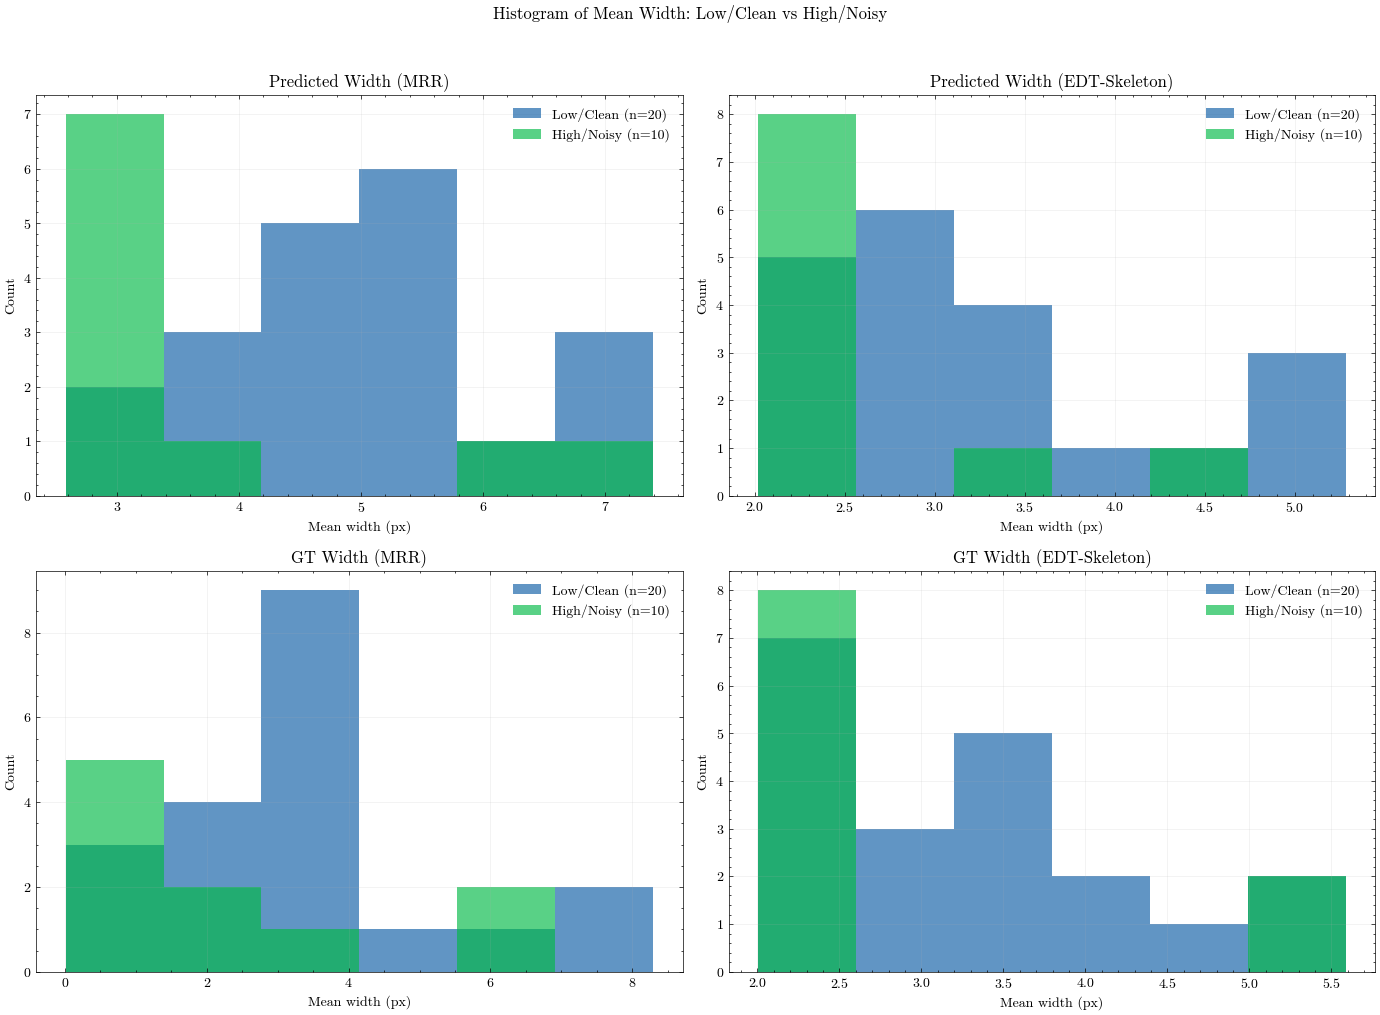

In [17]:
hist_width_specs = [
    ("pred_mean_width_px", "Predicted Width (MRR)"),
    ("pred_mean_width_px_edt_skel", "Predicted Width (EDT-Skeleton)"),
    ("gt_mean_width_px", "GT Width (MRR)"),
    ("gt_mean_width_px_edt_skel", "GT Width (EDT-Skeleton)"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (width_col, title) in zip(axes, hist_width_specs):
    plot_df = df_stats[[width_col, "noise_std", "noise_group"]].dropna(subset=[width_col, "noise_std"]).copy()

    # Normalize the class labels so both legacy and new names work.
    group_raw = plot_df["noise_group"].astype(str).str.strip().str.lower()
    plot_df["noise_group_norm"] = np.where(
        group_raw.str.contains("low|clean", na=False),
        "Low Noise",
        np.where(group_raw.str.contains("high|noisy", na=False), "High Noise", np.nan),
    )

    # Fallback for rows with unknown labels: split by median noise_std.
    missing_group = plot_df["noise_group_norm"].isna()
    if missing_group.any():
        median_noise = float(plot_df["noise_std"].median())
        plot_df.loc[missing_group, "noise_group_norm"] = np.where(
            plot_df.loc[missing_group, "noise_std"] <= median_noise,
            "Low Noise",
            "High Noise",
        )

    low_vals = plot_df.loc[plot_df["noise_group_norm"] == "Low Noise", width_col].astype(float)
    high_vals = plot_df.loc[plot_df["noise_group_norm"] == "High Noise", width_col].astype(float)

    bins = np.histogram_bin_edges(plot_df[width_col].astype(float), bins="auto")
    ax.hist(low_vals, bins=bins, alpha=0.65, label=f"Low/Clean (n={len(low_vals)})")
    ax.hist(high_vals, bins=bins, alpha=0.65, label=f"High/Noisy (n={len(high_vals)})")

    ax.set_title(title)
    ax.set_xlabel("Mean width (px)")
    ax.set_ylabel("Count")
    ax.legend()
    ax.grid(alpha=0.2)

plt.suptitle("Histogram of Mean Width: Low/Clean vs High/Noisy", y=1.02)
plt.tight_layout()

SAVE_PATH_HIST_NOISE_WIDTH = SAVE_DIR / "hist_mean_width_low_vs_high_noise_nanovision"
plt.savefig(f"{SAVE_PATH_HIST_NOISE_WIDTH}.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{SAVE_PATH_HIST_NOISE_WIDTH}.svg", bbox_inches="tight")

print(f"Saved: {SAVE_PATH_HIST_NOISE_WIDTH}.png")
print(f"Saved: {SAVE_PATH_HIST_NOISE_WIDTH}.svg")
plt.show()

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\precision_width\box_pred_width_mrr_low_vs_high_noise_um_nanovision.png
Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\precision_width\box_pred_width_mrr_low_vs_high_noise_um_nanovision.svg


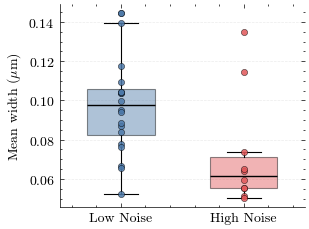

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\precision_width\box_pred_width_edt_skel_low_vs_high_noise_um_nanovision.png
Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\precision_width\box_pred_width_edt_skel_low_vs_high_noise_um_nanovision.svg


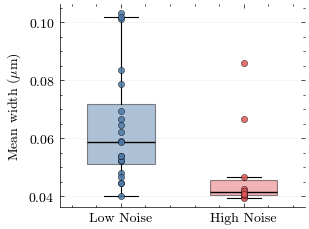

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\precision_width\box_gt_width_mrr_low_vs_high_noise_um_nanovision.png
Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\precision_width\box_gt_width_mrr_low_vs_high_noise_um_nanovision.svg


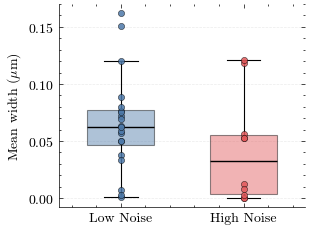

Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\precision_width\box_gt_width_edt_skel_low_vs_high_noise_um_nanovision.png
Saved: C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\precision_width\box_gt_width_edt_skel_low_vs_high_noise_um_nanovision.svg


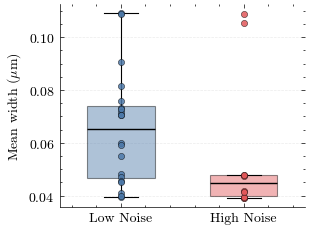

In [19]:
plt.style.use(["science", "no-latex"])

width_group_specs = [
    ("pred_mean_width_px", "Predicted width (MRR)", "box_pred_width_mrr_low_vs_high_noise"),
    ("pred_mean_width_px_edt_skel", "Predicted width (EDT-skeleton)", "box_pred_width_edt_skel_low_vs_high_noise"),
    ("gt_mean_width_px", "GT width (MRR)", "box_gt_width_mrr_low_vs_high_noise"),
    ("gt_mean_width_px_edt_skel", "GT width (EDT-skeleton)", "box_gt_width_edt_skel_low_vs_high_noise"),
]

NOISE_GROUP_COLORS = {
    "Low Noise": "#4C78A8",
    "High Noise": "#E15759",
}

def _prepare_width_noise_groups(df: pd.DataFrame, width_col: str) -> pd.DataFrame:
    plot_df = (
        df[[width_col, "noise_std", "noise_group"]]
        .dropna(subset=[width_col, "noise_std"])
        .copy()
    )

    group_raw = plot_df["noise_group"].astype(str).str.strip().str.lower()

    plot_df["noise_group_norm"] = np.where(
        group_raw.str.contains("low|clean", na=False),
        "Low Noise",
        np.where(
            group_raw.str.contains("high|noisy", na=False),
            "High Noise",
            np.nan,
        ),
    )

    missing_group = plot_df["noise_group_norm"].isna()

    if missing_group.any():
        median_noise = float(plot_df["noise_std"].median())
        plot_df.loc[missing_group, "noise_group_norm"] = np.where(
            plot_df.loc[missing_group, "noise_std"] <= median_noise,
            "Low Noise",
            "High Noise",
        )

    plot_df[width_col] = pd.to_numeric(plot_df[width_col], errors="coerce")
    plot_df = plot_df.dropna(subset=[width_col])

    # Convert width from pixels to micrometers for plotting
    plot_df["mean_width_um_for_plot"] = plot_df[width_col] * MICRONS_PER_PIXEL

    return plot_df


for width_col, title, filename_stem in width_group_specs:
    plot_df = _prepare_width_noise_groups(df_stats, width_col)

    plot_col = "mean_width_um_for_plot"

    low_vals = (
        plot_df.loc[plot_df["noise_group_norm"].eq("Low Noise"), plot_col]
        .astype(float)
        .dropna()
        .to_numpy()
    )

    high_vals = (
        plot_df.loc[plot_df["noise_group_norm"].eq("High Noise"), plot_col]
        .astype(float)
        .dropna()
        .to_numpy()
    )

    data = [low_vals, high_vals]
    positions = [1, 2]
    labels = ["Low Noise", "High Noise"]

    fig, ax = plt.subplots(figsize=(3.3, 2.5))

    box = ax.boxplot(
        data,
        positions=positions,
        widths=0.55,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.0),
        boxprops=dict(edgecolor="black", linewidth=0.8),
        whiskerprops=dict(color="black", linewidth=0.8),
        capprops=dict(color="black", linewidth=0.8),
    )

    for patch, label in zip(box["boxes"], labels):
        patch.set_facecolor(NOISE_GROUP_COLORS[label])
        patch.set_alpha(0.45)

    for x_pos, vals, label in zip(positions, data, labels):
        ax.scatter(
            np.full(len(vals), x_pos),
            vals,
            s=20,
            color=NOISE_GROUP_COLORS[label],
            edgecolor="black",
            linewidth=0.35,
            alpha=0.85,
            zorder=3,
        )

    # ax.set_title(title)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)
    ax.set_ylabel(r"Mean width ($\mu$m)")
    ax.set_xlabel("")

    ax.tick_params(direction="in")
    ax.yaxis.set_ticks_position("both")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.25)
    ax.set_axisbelow(True)

    fig.tight_layout()

    save_path = SAVE_DIR / f"{filename_stem}_um_nanovision"

    fig.savefig(f"{save_path}.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(f"{save_path}.svg", bbox_inches="tight", pad_inches=0.02)

    print(f"Saved: {save_path}.png")
    print(f"Saved: {save_path}.svg")

    plt.show()

### Statistical Significance: Width Difference by Noise Group

Two-sample Welch t-tests (unequal variance) are run for each width metric:
- Predicted width (MRR)
- Predicted width (EDT-Skeleton)
- GT width (MRR)
- GT width (EDT-Skeleton)

Significance rule: p-value < 0.05

In [20]:
from scipy.stats import ttest_ind

ttest_specs = [
    ("pred_mean_width_px", "Predicted Width (MRR)", "px"),
    ("pred_mean_width_px_edt_skel", "Predicted Width (EDT-Skeleton)", "px"),
    ("gt_mean_width_px", "GT Width (MRR)", "px"),
    ("gt_mean_width_px_edt_skel", "GT Width (EDT-Skeleton)", "px"),

    ("pred_mean_width_px", "Predicted Width (MRR)", "um"),
    ("pred_mean_width_px_edt_skel", "Predicted Width (EDT-Skeleton)", "um"),
    ("gt_mean_width_px", "GT Width (MRR)", "um"),
    ("gt_mean_width_px_edt_skel", "GT Width (EDT-Skeleton)", "um"),
]

ttest_rows = []
ttest_audit_rows = []

for width_col, label, unit in ttest_specs:
    stage1_df = df_stats[[width_col, "noise_std", "noise_group"]].copy()
    stage1_rows_before = int(len(stage1_df))
    test_df = stage1_df.dropna(subset=[width_col, "noise_std"]).copy()
    stage1_rows_after = int(len(test_df))

    # Convert to micron when requested
    value_col = width_col
    if unit == "um":
        value_col = f"{width_col}_um_tmp"
        test_df[value_col] = pd.to_numeric(test_df[width_col], errors="coerce") * MICRONS_PER_PIXEL
    else:
        test_df[value_col] = pd.to_numeric(test_df[width_col], errors="coerce")

    test_df = test_df.dropna(subset=[value_col])

    group_raw = test_df["noise_group"].astype(str).str.strip().str.lower()
    test_df["noise_group_norm"] = np.where(
        group_raw.str.contains("low|clean", na=False),
        "Low Noise",
        np.where(group_raw.str.contains("high|noisy", na=False), "High Noise", np.nan),
    )

    stage2_low = int((test_df["noise_group_norm"] == "Low Noise").sum())
    stage2_high = int((test_df["noise_group_norm"] == "High Noise").sum())
    stage2_unknown = int(test_df["noise_group_norm"].isna().sum())

    missing_group = test_df["noise_group_norm"].isna()
    stage3_fallback_rows = int(missing_group.sum())
    stage3_median_noise = np.nan

    if missing_group.any():
        stage3_median_noise = float(test_df["noise_std"].median())
        test_df.loc[missing_group, "noise_group_norm"] = np.where(
            test_df.loc[missing_group, "noise_std"] <= stage3_median_noise,
            "Low Noise",
            "High Noise",
        )

    stage3_low = int((test_df["noise_group_norm"] == "Low Noise").sum())
    stage3_high = int((test_df["noise_group_norm"] == "High Noise").sum())
    stage3_unknown_after = int(test_df["noise_group_norm"].isna().sum())

    low_vals = (
        test_df.loc[test_df["noise_group_norm"] == "Low Noise", value_col]
        .astype(float)
        .dropna()
    )

    high_vals = (
        test_df.loc[test_df["noise_group_norm"] == "High Noise", value_col]
        .astype(float)
        .dropna()
    )

    if len(low_vals) >= 2 and len(high_vals) >= 2:
        stat, pval = ttest_ind(low_vals, high_vals, equal_var=False, nan_policy="omit")
        significant = bool(pval < 0.05)
    else:
        stat, pval, significant = np.nan, np.nan, False

    ttest_rows.append({
        "metric": label,
        "unit": unit,
        "source_column": width_col,
        "n_low_clean": int(len(low_vals)),
        "n_high_noisy": int(len(high_vals)),
        "mean_low_clean": float(low_vals.mean()) if len(low_vals) > 0 else np.nan,
        "mean_high_noisy": float(high_vals.mean()) if len(high_vals) > 0 else np.nan,
        "mean_difference_low_minus_high": (
            float(low_vals.mean() - high_vals.mean())
            if len(low_vals) > 0 and len(high_vals) > 0
            else np.nan
        ),
        "welch_t_stat": float(stat) if np.isfinite(stat) else np.nan,
        "p_value": float(pval) if np.isfinite(pval) else np.nan,
        "significant_p_lt_0_05": significant,
    })

    ttest_audit_rows.append({
        "metric": label,
        "unit": unit,
        "source_column": width_col,
        "stage1_rows_before_dropna": stage1_rows_before,
        "stage1_rows_after_dropna": stage1_rows_after,
        "stage2_low_from_labels": stage2_low,
        "stage2_high_from_labels": stage2_high,
        "stage2_unknown_labels": stage2_unknown,
        "stage3_rows_using_fallback": stage3_fallback_rows,
        "stage3_median_noise_for_fallback": stage3_median_noise,
        "stage3_final_low": stage3_low,
        "stage3_final_high": stage3_high,
        "stage3_unknown_after_fallback": stage3_unknown_after,
        "stage4_n_low_values": int(len(low_vals)),
        "stage4_n_high_values": int(len(high_vals)),
    })

ttest_results_df = pd.DataFrame(ttest_rows)
ttest_audit_df = pd.DataFrame(ttest_audit_rows)

print("Audit table (what happened at each stage):")
display(ttest_audit_df)

print("\nFinal Welch t-test results:")
display(ttest_results_df)

print("\nSignificance summary (p < 0.05):")
for _, row in ttest_results_df.iterrows():
    status = "SIGNIFICANT" if row["significant_p_lt_0_05"] else "not significant"
    print(
        f"- {row['metric']} [{row['unit']}]: {status} "
        f"(p={row['p_value']:.4g}, "
        f"n_low={int(row['n_low_clean'])}, "
        f"n_high={int(row['n_high_noisy'])})"
    )

Audit table (what happened at each stage):


,metric,unit,source_column,stage1_rows_before_dropna,stage1_rows_after_dropna,stage2_low_from_labels,stage2_high_from_labels,stage2_unknown_labels,stage3_rows_using_fallback,stage3_median_noise_for_fallback,stage3_final_low,stage3_final_high,stage3_unknown_after_fallback,stage4_n_low_values,stage4_n_high_values
0,Predicted Width (MRR),px,pred_mean_width_px,30,30,20,10,0,0,NaN,20,10,0,20,10
1,Predicted Width (EDT-Skeleton),px,pred_mean_width_px_edt_skel,30,30,20,10,0,0,NaN,20,10,0,20,10
2,GT Width (MRR),px,gt_mean_width_px,30,30,20,10,0,0,NaN,20,10,0,20,10
3,GT Width (EDT-Skeleton),px,gt_mean_width_px_edt_skel,30,30,20,10,0,0,NaN,20,10,0,20,10
4,Predicted Width (MRR),um,pred_mean_width_px,30,30,20,10,0,0,NaN,20,10,0,20,10
5,Predicted Width (EDT-Skeleton),um,pred_mean_width_px_edt_skel,30,30,20,10,0,0,NaN,20,10,0,20,10
6,GT Width (MRR),um,gt_mean_width_px,30,30,20,10,0,0,NaN,20,10,0,20,10
7,GT Width (EDT-Skeleton),um,gt_mean_width_px_edt_skel,30,30,20,10,0,0,NaN,20,10,0,20,10



Final Welch t-test results:


,metric,unit,source_column,n_low_clean,n_high_noisy,mean_low_clean,mean_high_noisy,mean_difference_low_minus_high,welch_t_stat,p_value,significant_p_lt_0_05
0,Predicted Width (MRR),px,pred_mean_width_px,20,10,5.011999,3.705975,1.306023,2.375985,0.030247,True
1,Predicted Width (EDT-Skeleton),px,pred_mean_width_px_edt_skel,20,10,3.290812,2.484166,0.806646,2.385562,0.025877,True
2,GT Width (MRR),px,gt_mean_width_px,20,10,3.370286,2.171206,1.199079,1.336099,0.199428,False
3,GT Width (EDT-Skeleton),px,gt_mean_width_px_edt_skel,20,10,3.340369,2.857259,0.483110,0.957902,0.353696,False
4,Predicted Width (MRR),um,pred_mean_width_px,20,10,0.097891,0.072382,0.025508,2.375985,0.030247,True
5,Predicted Width (EDT-Skeleton),um,pred_mean_width_px_edt_skel,20,10,0.064274,0.048519,0.015755,2.385562,0.025877,True
6,GT Width (MRR),um,gt_mean_width_px,20,10,0.065826,0.042406,0.023420,1.336099,0.199428,False
7,GT Width (EDT-Skeleton),um,gt_mean_width_px_edt_skel,20,10,0.065242,0.055806,0.009436,0.957902,0.353696,False



Significance summary (p < 0.05):
- Predicted Width (MRR) [px]: SIGNIFICANT (p=0.03025, n_low=20, n_high=10)
- Predicted Width (EDT-Skeleton) [px]: SIGNIFICANT (p=0.02588, n_low=20, n_high=10)
- GT Width (MRR) [px]: not significant (p=0.1994, n_low=20, n_high=10)
- GT Width (EDT-Skeleton) [px]: not significant (p=0.3537, n_low=20, n_high=10)
- Predicted Width (MRR) [um]: SIGNIFICANT (p=0.03025, n_low=20, n_high=10)
- Predicted Width (EDT-Skeleton) [um]: SIGNIFICANT (p=0.02588, n_low=20, n_high=10)
- GT Width (MRR) [um]: not significant (p=0.1994, n_low=20, n_high=10)
- GT Width (EDT-Skeleton) [um]: not significant (p=0.3537, n_low=20, n_high=10)


## Audit

In [21]:
gt_ids = set(gt_stats_df["image_id"])
pred_ids = set(pred_stats_df["image_id"])
metric_ids = set(metrics_df["image_id"])
noise_ids = set(noise_df["image_id"])
final_ids = set(df_stats["image_id"])

print("GT geometry images:", len(gt_ids))
print("Prediction geometry images:", len(pred_ids))
print("Metrics images:", len(metric_ids))
print("Noise images:", len(noise_ids))
print("Final images:", len(final_ids))

print("\nMissing prediction geometry for GT images:", len(gt_ids - pred_ids))
print("Missing metrics for GT images:", len(gt_ids - metric_ids))
print("Missing noise for GT images:", len(gt_ids - noise_ids))

print("\nPrediction images not in GT:", len(pred_ids - gt_ids))
print("Metric images not in GT:", len(metric_ids - gt_ids))
print("Noise images not in GT:", len(noise_ids - gt_ids))

print("\nExamples missing prediction geometry:", sorted(list(gt_ids - pred_ids))[:10])
print("Examples missing metrics:", sorted(list(gt_ids - metric_ids))[:10])
print("Examples missing noise:", sorted(list(gt_ids - noise_ids))[:10])

GT geometry images: 30
Prediction geometry images: 30
Metrics images: 30
Noise images: 30
Final images: 30

Missing prediction geometry for GT images: 0
Missing metrics for GT images: 0
Missing noise for GT images: 0

Prediction images not in GT: 0
Metric images not in GT: 0
Noise images not in GT: 0

Examples missing prediction geometry: []
Examples missing metrics: []
Examples missing noise: []


In [22]:
df_stats["width_abs_diff_px"] = (
    df_stats["pred_mean_width_px"] - df_stats["gt_mean_width_px"]
).abs()

df_stats["width_abs_diff_um"] = (
    df_stats["pred_mean_width_um"] - df_stats["gt_mean_width_um"]
).abs()

display(
    df_stats[[
        "image_id",
        "gt_mean_width_px",
        "pred_mean_width_px",
        "width_abs_diff_px",
        "gt_n_objects",
        "pred_n_objects",
        "TP",
        "FP",
        "FN",
        "precision",
        "noise_std",
    ]].sort_values("width_abs_diff_px", ascending=False)
)

print(df_stats[[
    "gt_mean_width_px",
    "pred_mean_width_px",
    "width_abs_diff_px",
    "gt_mean_width_um",
    "pred_mean_width_um",
    "width_abs_diff_um",
]].describe())

,image_id,gt_mean_width_px,pred_mean_width_px,width_abs_diff_px,gt_n_objects,pred_n_objects,TP,FP,FN,precision,noise_std
24,400-1605-w7_map_00028_3,0.378680,4.287418,3.908739,59,75,58,17,1,0.773333,8.895480
26,400-1605-w8_map_00038_3,1.700442,5.347611,3.647169,28,27,23,4,5,0.851852,11.119343
27,400-1605-w8_map_00047_3,0.148337,3.349814,3.201477,48,78,45,33,3,0.576923,11.860638
28,400-1605-w8_map_00049_1,0.643125,3.335283,2.692158,71,86,62,24,10,0.720930,21.497400
20,400-1605-w3_map_00034_1,0.134969,2.825423,2.690454,60,85,58,27,4,0.682353,17.790959
17,400-1605-w1_map_00030_bottom_right,0.010399,2.638471,2.628072,58,107,55,52,3,0.514019,19.273536
22,400-1605-w3_map_00041_1,0.063228,2.675728,2.612501,68,126,66,60,2,0.523810,12.601929
18,400-1605-w1_map_00039_bottom_left,0.017424,2.580025,2.562601,68,108,65,43,4,0.601852,17.049665
29,400-1605-w8_map_00049_top_right,0.392266,2.826661,2.434395,56,69,51,18,7,0.739130,17.049661
8,400-1293-17-c3k1r5_pd_sp0_3_fl0_1_right,3.247063,5.593322,2.346259,11,11,11,0,0,1.000000,10.378053


       gt_mean_width_px  pred_mean_width_px  width_abs_diff_px  \
count         30.000000           30.000000          30.000000   
mean           2.970593            4.576657           1.726272   
std            2.281159            1.472040           0.985789   
min            0.010399            2.580025           0.319271   
25%            0.907454            3.338916           0.876952   
50%            2.893358            4.487269           1.503521   
75%            3.911507            5.348296           2.530550   
max            8.293053            7.394366           3.908739   

       gt_mean_width_um  pred_mean_width_um  width_abs_diff_um  
count         30.000000           30.000000          30.000000  
mean           0.058019            0.089388           0.033716  
std            0.044554            0.028751           0.019254  
min            0.000203            0.050391           0.006236  
25%            0.017724            0.065213           0.017128  
50%            

## Correlation Figures
Standardized naming is used below:
- Predicted width (MRR): mean width from predicted polygons using minimum rotated rectangle.
- GT width (MRR): mean width from GT polygons using minimum rotated rectangle.
- GT width (EDT-Skeleton): 2 * mean EDT over skeleton pixels per GT annotation.

In [23]:
def _retitle_current_figure(title: str) -> None:
    ax = plt.gca()
    ax.set_title(title)
    plt.tight_layout()

### Classical Precision vs Predicted Width (MRR)

{'slope': 6.644836590686293,
 'intercept': 0.18224778450934742,
 'pearson_r': 0.9449724786385562,
 'pvalue': 1.1205389424663328e-08}

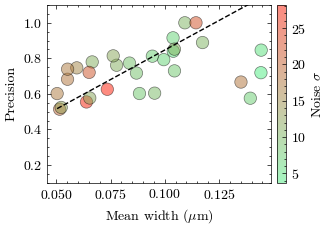

In [24]:
SAVE_PATH_PRED_WIDTH = SAVE_DIR / "classical_precision_vs_predicted_width_mrr_nanovision"

results_pred_width = precision_vs_width(
    mean_width_px=df_stats["pred_mean_width_px"],
    precision=df_stats["precision"],
    noise=df_stats["noise_std"],
    save_path=SAVE_PATH_PRED_WIDTH,
    figsize=(3.5, 2.5),

)

results_pred_width

### Classical Precision vs Predicted Width (EDT-Skeleton)

{'slope': 6.46589459990154,
 'intercept': 0.42356759923970294,
 'pearson_r': 0.8924777788089541,
 'pvalue': 1.2275568134617082e-07}

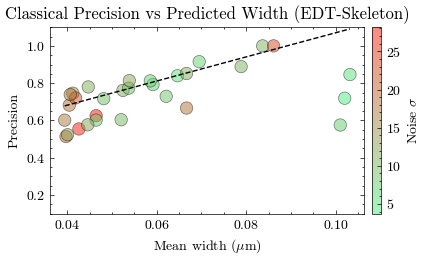

In [23]:
df_stats_pred_edt = df_stats.dropna(subset=["pred_mean_width_px_edt_skel"]).copy()

SAVE_PATH_PREC_PRED_EDT_WIDTH = SAVE_DIR / "precision_vs_pred_edt_skel_width_nanovision"

results_prec_pred_edt_width = precision_vs_width(
    mean_width_px=df_stats_pred_edt["pred_mean_width_px_edt_skel"],
    precision=df_stats_pred_edt["precision"],
    noise=df_stats_pred_edt["noise_std"],
    save_path=SAVE_PATH_PREC_PRED_EDT_WIDTH
)
_retitle_current_figure("Classical Precision vs Predicted Width (EDT-Skeleton)")

results_prec_pred_edt_width

### DSB AP@0.05 vs Predicted Width (MRR)

{'slope': 2.3115660864778187,
 'intercept': 0.527986849835123,
 'pearson_r': 0.7198128755521387,
 'pvalue': 0.0011220606240570448}

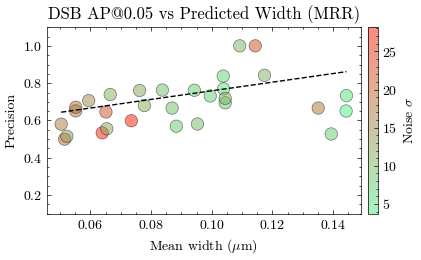

In [24]:
SAVE_PATH_DSB_AP005_PRED_WIDTH = SAVE_DIR / "dsb_ap005_vs_pred_width_nanovision"

results_dsb_ap005_pred_width = precision_vs_width(
    mean_width_px=df_stats["pred_mean_width_px"],
    precision=df_stats["dsb_ap_005"],
    noise=df_stats["noise_std"],
    save_path=SAVE_PATH_DSB_AP005_PRED_WIDTH
)
_retitle_current_figure("DSB AP@0.05 vs Predicted Width (MRR)")

results_dsb_ap005_pred_width

### DSB mAP vs Predicted Width (MRR)

{'slope': 1.7074061445427384,
 'intercept': 0.111734667043381,
 'pearson_r': 0.8336315567277504,
 'pvalue': 4.984769791407199e-06}

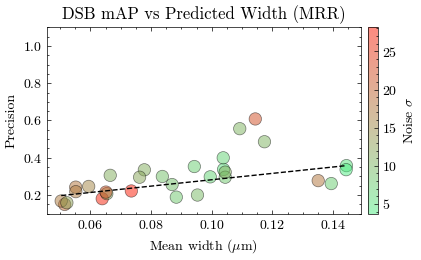

In [25]:
SAVE_PATH_DSB_MAP_PRED_WIDTH = SAVE_DIR / "dsb_map_vs_pred_width_nanovision"

results_dsb_map_pred_width = precision_vs_width(
    mean_width_px=df_stats["pred_mean_width_px"],
    precision=df_stats["dsb_map"],
    noise=df_stats["noise_std"],
    save_path=SAVE_PATH_DSB_MAP_PRED_WIDTH
)
_retitle_current_figure("DSB mAP vs Predicted Width (MRR)")

results_dsb_map_pred_width

### DSB mAP vs Predicted Width (EDT-Skeleton)

{'slope': 8.37584786416356,
 'intercept': -0.17193351368368948,
 'pearson_r': 0.9629012061666833,
 'pvalue': 7.646471173842528e-13}

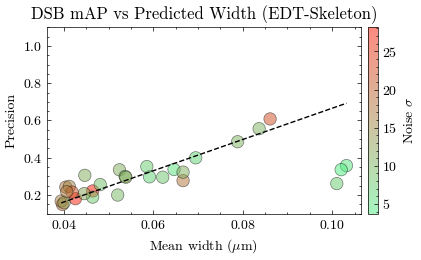

In [26]:
df_stats_pred_edt = df_stats.dropna(subset=["pred_mean_width_px_edt_skel"]).copy()

SAVE_PATH_DSB_MAP_PRED_EDT_WIDTH = SAVE_DIR / "dsb_map_vs_pred_edt_skel_width_nanovision"

results_dsb_map_pred_edt_width = precision_vs_width(
    mean_width_px=df_stats_pred_edt["pred_mean_width_px_edt_skel"],
    precision=df_stats_pred_edt["dsb_map"],
    noise=df_stats_pred_edt["noise_std"],
    save_path=SAVE_PATH_DSB_MAP_PRED_EDT_WIDTH
)
_retitle_current_figure("DSB mAP vs Predicted Width (EDT-Skeleton)")

results_dsb_map_pred_edt_width

### DSB AP@0.05 vs Predicted Width (EDT-Skeleton)

{'slope': 4.829066338456634,
 'intercept': 0.454063744223628,
 'pearson_r': 0.7813721107616708,
 'pvalue': 0.00012870329167055701}

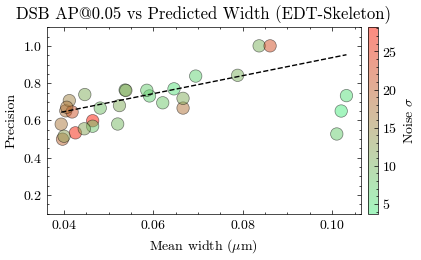

In [27]:
df_stats_pred_edt = df_stats.dropna(subset=["pred_mean_width_px_edt_skel"]).copy()

SAVE_PATH_DSB_AP005_PRED_EDT_WIDTH = SAVE_DIR / "dsb_ap005_vs_pred_edt_skel_width_nanovision"

results_dsb_ap005_pred_edt_width = precision_vs_width(
    mean_width_px=df_stats_pred_edt["pred_mean_width_px_edt_skel"],
    precision=df_stats_pred_edt["dsb_ap_005"],
    noise=df_stats_pred_edt["noise_std"],
    save_path=SAVE_PATH_DSB_AP005_PRED_EDT_WIDTH
)
_retitle_current_figure("DSB AP@0.05 vs Predicted Width (EDT-Skeleton)")

results_dsb_ap005_pred_edt_width

### F1@0.05 vs Predicted Width (EDT-Skeleton)

### F1@0.05 vs Predicted Width (MRR)

{'slope': 1.5709557767896813,
 'intercept': 0.7049925081027957,
 'pearson_r': 0.7202959912948217,
 'pvalue': 0.001109360504426973}

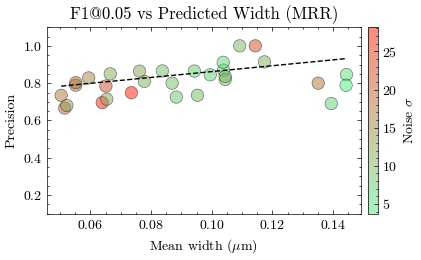

In [28]:
SAVE_PATH_F1_005_PRED_WIDTH = SAVE_DIR / "f1_005_vs_pred_width_nanovision"

results_f1_005_pred_width = precision_vs_width(
    mean_width_px=df_stats["pred_mean_width_px"],
    precision=df_stats["f1_005"],
    noise=df_stats["noise_std"],
    save_path=SAVE_PATH_F1_005_PRED_WIDTH
)
_retitle_current_figure("F1@0.05 vs Predicted Width (MRR)")

results_f1_005_pred_width

{'slope': 3.071102924428729,
 'intercept': 0.669294472828194,
 'pearson_r': 0.7869107521782267,
 'pvalue': 0.00017828018815218145}

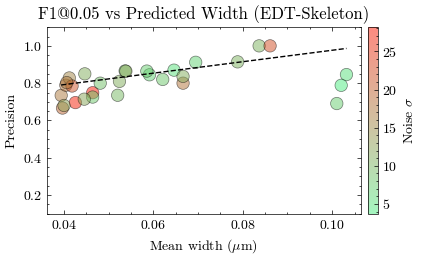

In [29]:
SAVE_PATH_F1_005_PRED_EDT_WIDTH = SAVE_DIR / "f1_005_vs_pred_edt_skel_width_nanovision"

results_f1_005_pred_edt_width = precision_vs_width(
    mean_width_px=df_stats_pred_edt["pred_mean_width_px_edt_skel"],
    precision=df_stats_pred_edt["f1_005"],
    noise=df_stats_pred_edt["noise_std"],
    save_path=SAVE_PATH_F1_005_PRED_EDT_WIDTH
)
_retitle_current_figure("F1@0.05 vs Predicted Width (EDT-Skeleton)")

results_f1_005_pred_edt_width

### F1@0.05 vs Noise Std (Predicted Width EDT-Skeleton subset)

{'slope': -0.005968697426625427,
 'intercept': 0.9006076109934185,
 'pearson_r': -0.8532947730188424,
 'pvalue': 3.4147501337645774e-06}

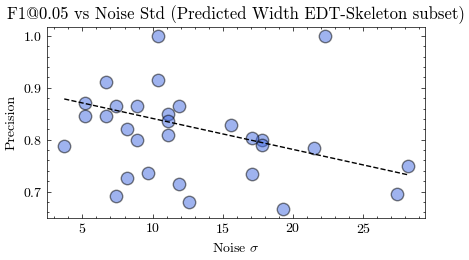

In [30]:
SAVE_PATH_F1_005_NOISE_PRED_EDT = SAVE_DIR / "f1_005_vs_noise_pred_edt_skel_subset_nanovision"

results_f1_005_noise_pred_edt = precision_vs_noise(
    precision=df_stats_pred_edt["f1_005"],
    noise=df_stats_pred_edt["noise_std"],
    save_path=SAVE_PATH_F1_005_NOISE_PRED_EDT
)
_retitle_current_figure("F1@0.05 vs Noise Std (Predicted Width EDT-Skeleton subset)")

results_f1_005_noise_pred_edt

### Classical Precision vs GT Width (MRR)

{'slope': 2.190990211188739,
 'intercept': 0.673140146764908,
 'pearson_r': 0.8223372317788399,
 'pvalue': 1.555283231155068e-05}

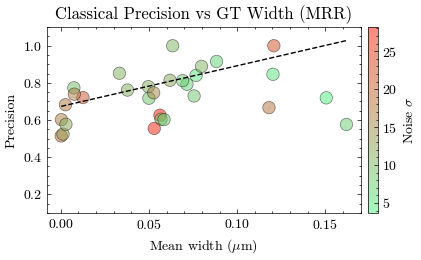

In [31]:
SAVE_PATH_GT_WIDTH = SAVE_DIR / "precision_vs_gt_width_nanovision"

results_gt_width = precision_vs_width(
    mean_width_px=df_stats["gt_mean_width_px"],
    precision=df_stats["precision"],
    noise=df_stats["noise_std"],
    save_path=SAVE_PATH_GT_WIDTH
)
_retitle_current_figure("Classical Precision vs GT Width (MRR)")

results_gt_width

### Classical Precision vs GT Width (EDT-Skeleton)

{'slope': 4.5387810544333025,
 'intercept': 0.5059482344222447,
 'pearson_r': 0.8527283374703708,
 'pvalue': 3.521324487999543e-06}

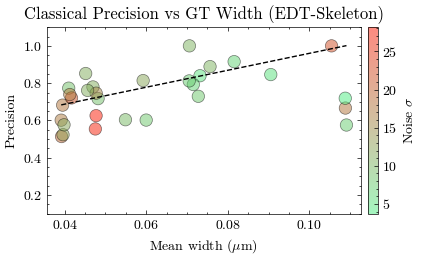

In [32]:
df_stats_edt = df_stats.dropna(subset=["gt_mean_width_px_edt_skel"]).copy()

SAVE_PATH_GT_EDT_WIDTH = SAVE_DIR / "precision_vs_gt_edt_skel_width_nanovision"

results_gt_edt_width = precision_vs_width(
    mean_width_px=df_stats_edt["gt_mean_width_px_edt_skel"],
    precision=df_stats_edt["precision"],
    noise=df_stats_edt["noise_std"],
    save_path=SAVE_PATH_GT_EDT_WIDTH
)
_retitle_current_figure("Classical Precision vs GT Width (EDT-Skeleton)")

results_gt_edt_width

### Regression Summary (Classical Precision vs GT Width MRR)

In [33]:
print("---- PRECISION vs GT WIDTH RESULTS ----")
print(f"Slope:       {results_gt_width['slope']:.4f}")
print(f"Intercept:   {results_gt_width['intercept']:.4f}")
print(f"Pearson r:   {results_gt_width['pearson_r']:.4f}")
print(f"P-value:     {results_gt_width['pvalue']:.2e}")

print("\nFigure saved at:")
print(f"{SAVE_PATH_GT_WIDTH}.svg")
print(f"{SAVE_PATH_GT_WIDTH}.png")

---- PRECISION vs GT WIDTH RESULTS ----
Slope:       2.1910
Intercept:   0.6731
Pearson r:   0.8223
P-value:     1.56e-05

Figure saved at:
C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\precision_width\precision_vs_gt_width_nanovision.svg
C:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\paper_figures\outputs\precision_width\precision_vs_gt_width_nanovision.png


### Noise Std vs Width

### Noise Std vs Predicted Width (EDT-Skeleton)

c:\Users\abd93000\PycharmProjects\cnt_project_v2\src\cnt_project\visualizations\experiments\paper_figures\correlation_plots.py:90: UserWarning: No data for colormapping provided via 'c'. Parameters 'norm' will be ignored
  ax.scatter(


{'slope': -0.0008183323850839063,
 'intercept': 0.059355239734916944,
 'pearson_r': -0.6647610258049678,
 'pvalue': 0.0010107441528117778}

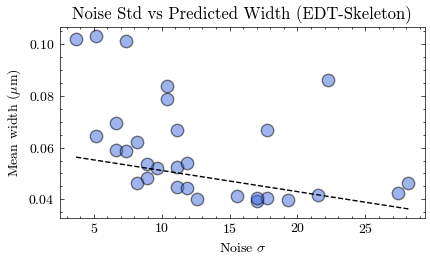

In [34]:
SAVE_PATH_NOISE_PRED_EDT = SAVE_DIR / "noise_vs_pred_edt_skel_width_nanovision"

results_noise_pred_edt = noise_vs_width(
    mean_width_px=df_stats_pred_edt["pred_mean_width_px_edt_skel"],
    noise=df_stats_pred_edt["noise_std"],
    save_path=SAVE_PATH_NOISE_PRED_EDT
)
_retitle_current_figure("Noise Std vs Predicted Width (EDT-Skeleton)")

results_noise_pred_edt

c:\Users\abd93000\PycharmProjects\cnt_project_v2\src\cnt_project\visualizations\experiments\paper_figures\correlation_plots.py:90: UserWarning: No data for colormapping provided via 'c'. Parameters 'norm' will be ignored
  ax.scatter(


{'slope': -0.0035411453090671984,
 'intercept': 0.11978918940268246,
 'pearson_r': -0.8936889435851949,
 'pvalue': 2.5502668008699235e-07}

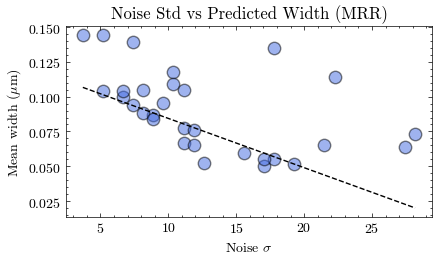

In [35]:
SAVE_PATH_NOISE = SAVE_DIR / "noise_vs_width_pred_nanovision"

results_noise = noise_vs_width(
    mean_width_px=df_stats["pred_mean_width_px"],
    noise=df_stats["noise_std"],
    save_path=SAVE_PATH_NOISE
)
_retitle_current_figure("Noise Std vs Predicted Width (MRR)")

results_noise

c:\Users\abd93000\PycharmProjects\cnt_project_v2\src\cnt_project\visualizations\experiments\paper_figures\correlation_plots.py:90: UserWarning: No data for colormapping provided via 'c'. Parameters 'norm' will be ignored
  ax.scatter(


{'slope': -0.0063578614478879665,
 'intercept': 0.11739130627370466,
 'pearson_r': -0.9447370259224658,
 'pvalue': 1.1562034900110173e-08}

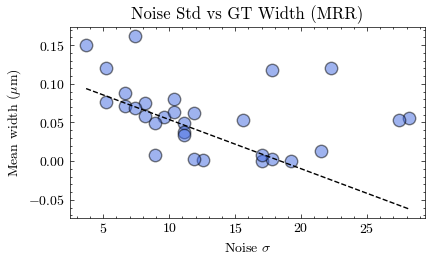

In [36]:
SAVE_PATH_NOISE_GT = SAVE_DIR / "noise_vs_gt_width_nanovision"

results_noise_gt = noise_vs_width(
    mean_width_px=df_stats["gt_mean_width_px"],
    noise=df_stats["noise_std"],
    save_path=SAVE_PATH_NOISE_GT
)
_retitle_current_figure("Noise Std vs GT Width (MRR)")

results_noise_gt

### Noise Std vs GT Width (EDT-Skeleton)

c:\Users\abd93000\PycharmProjects\cnt_project_v2\src\cnt_project\visualizations\experiments\paper_figures\correlation_plots.py:90: UserWarning: No data for colormapping provided via 'c'. Parameters 'norm' will be ignored
  ax.scatter(


{'slope': -0.0026137600928937336,
 'intercept': 0.08930153622795331,
 'pearson_r': -0.9235837494232599,
 'pvalue': 8.988899930127719e-07}

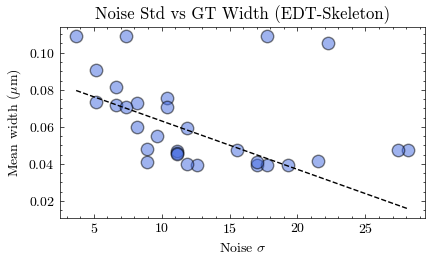

In [37]:
SAVE_PATH_NOISE_GT_EDT = SAVE_DIR / "noise_vs_gt_edt_skel_width_nanovision"

results_noise_gt_edt = noise_vs_width(
    mean_width_px=df_stats_edt["gt_mean_width_px_edt_skel"],
    noise=df_stats_edt["noise_std"],
    save_path=SAVE_PATH_NOISE_GT_EDT
)
_retitle_current_figure("Noise Std vs GT Width (EDT-Skeleton)")

results_noise_gt_edt

### Classical Precision vs Noise Std

### Classical Precision vs Noise Std (Predicted Width EDT-Skeleton subset)

{'slope': -0.010746262085447492,
 'intercept': 0.8907568512190778,
 'pearson_r': -0.8152343937041798,
 'pvalue': 1.1928324916910927e-05}

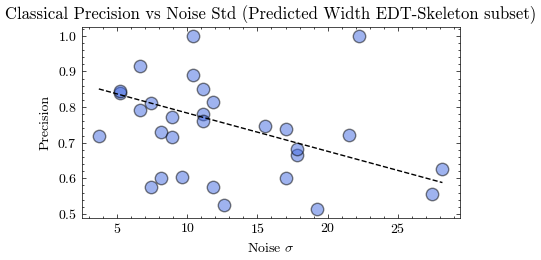

In [38]:
SAVE_PATH_PREC_NOISE_PRED_EDT = SAVE_DIR / "precision_vs_noise_pred_edt_skel_subset_nanovision"

results_prec_noise_pred_edt = precision_vs_noise(
    precision=df_stats_pred_edt["precision"],
    noise=df_stats_pred_edt["noise_std"],
    save_path=SAVE_PATH_PREC_NOISE_PRED_EDT
)
_retitle_current_figure("Classical Precision vs Noise Std (Predicted Width EDT-Skeleton subset)")

results_prec_noise_pred_edt

{'slope': -0.010746262085447492,
 'intercept': 0.8907568512190778,
 'pearson_r': -0.8152343937041798,
 'pvalue': 1.1928324916910927e-05}

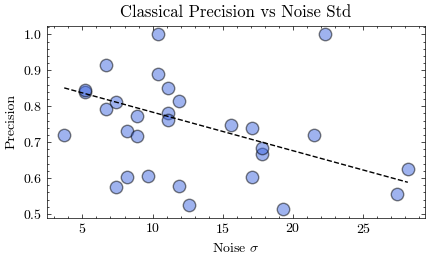

In [39]:
SAVE_PATH_PREC_NOISE = SAVE_DIR / "precision_vs_noise_nanovision"

results_prec_noise = precision_vs_noise(
    precision=df_stats["precision"],
    noise=df_stats["noise_std"],
    save_path=SAVE_PATH_PREC_NOISE
)
_retitle_current_figure("Classical Precision vs Noise Std")

results_prec_noise

### DSB AP@0.05 vs GT Width (MRR)

{'slope': 0.9758644089510383,
 'intercept': 0.6364652397486152,
 'pearson_r': 0.5670368684730431,
 'pvalue': 0.01412811264849204}

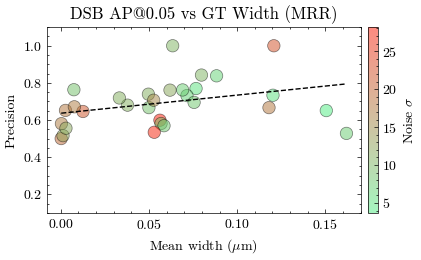

In [40]:
SAVE_PATH_DSB_AP005_GT_WIDTH = SAVE_DIR / "dsb_ap005_vs_gt_width_nanovision"

results_dsb_ap005_gt_width = precision_vs_width(
    mean_width_px=df_stats["gt_mean_width_px"],
    precision=df_stats["dsb_ap_005"],
    noise=df_stats["noise_std"],
    save_path=SAVE_PATH_DSB_AP005_GT_WIDTH
)
_retitle_current_figure("DSB AP@0.05 vs GT Width (MRR)")

results_dsb_ap005_gt_width

### DSB AP@0.05 vs GT Width (EDT-Skeleton)

{'slope': 3.863808534543064,
 'intercept': 0.49396031570083804,
 'pearson_r': 0.790031332408946,
 'pvalue': 0.0001611750001263859}

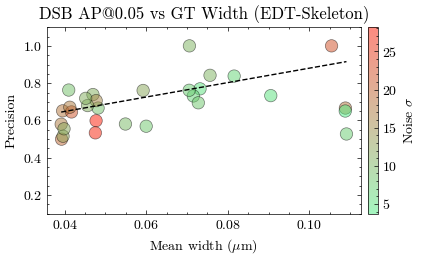

In [41]:
SAVE_PATH_DSB_AP005_GT_EDT_WIDTH = SAVE_DIR / "dsb_ap005_vs_gt_edt_skel_width_nanovision"

results_dsb_ap005_gt_edt_width = precision_vs_width(
    mean_width_px=df_stats_edt["gt_mean_width_px_edt_skel"],
    precision=df_stats_edt["dsb_ap_005"],
    noise=df_stats_edt["noise_std"],
    save_path=SAVE_PATH_DSB_AP005_GT_EDT_WIDTH
)
_retitle_current_figure("DSB AP@0.05 vs GT Width (EDT-Skeleton)")

results_dsb_ap005_gt_edt_width

### DSB mAP vs GT Width (MRR)

{'slope': 1.2485461004101155,
 'intercept': 0.19584314420514104,
 'pearson_r': 0.8682656384080345,
 'pvalue': 6.2162371709042736e-06}

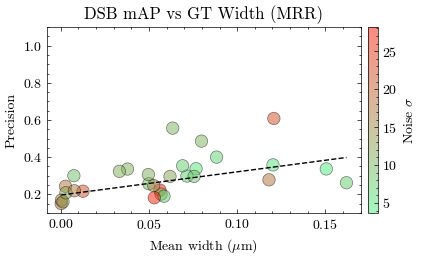

In [42]:
SAVE_PATH_DSB_MAP_GT_WIDTH = SAVE_DIR / "dsb_map_vs_gt_width_nanovision"

results_dsb_map_gt_width = precision_vs_width(
    mean_width_px=df_stats["gt_mean_width_px"],
    precision=df_stats["dsb_map"],
    noise=df_stats["noise_std"],
    save_path=SAVE_PATH_DSB_MAP_GT_WIDTH
)
_retitle_current_figure("DSB mAP vs GT Width (MRR)")

results_dsb_map_gt_width

### DSB mAP vs GT Width (EDT-Skeleton)

{'slope': 5.756655745805387,
 'intercept': -0.055123732643113654,
 'pearson_r': 0.9532410053633221,
 'pvalue': 3.3851738012900127e-09}

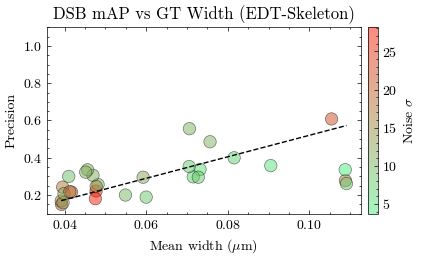

In [43]:
SAVE_PATH_DSB_MAP_GT_EDT_WIDTH = SAVE_DIR / "dsb_map_vs_gt_edt_skel_width_nanovision"

results_dsb_map_gt_edt_width = precision_vs_width(
    mean_width_px=df_stats_edt["gt_mean_width_px_edt_skel"],
    precision=df_stats_edt["dsb_map"],
    noise=df_stats_edt["noise_std"],
    save_path=SAVE_PATH_DSB_MAP_GT_EDT_WIDTH
)
_retitle_current_figure("DSB mAP vs GT Width (EDT-Skeleton)")

results_dsb_map_gt_edt_width

### DSB AP@0.05 vs Noise Std

{'slope': -0.008706332690771076,
 'intercept': 0.8108421519309199,
 'pearson_r': -0.8245919434130008,
 'pvalue': 7.7489562074021e-06}

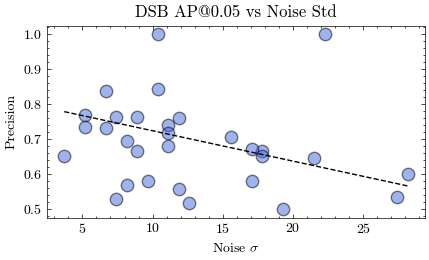

In [44]:
SAVE_PATH_DSB_AP005_NOISE = SAVE_DIR / "dsb_ap005_vs_noise_nanovision"

results_dsb_ap005_noise = precision_vs_noise(
    precision=df_stats["dsb_ap_005"],
    noise=df_stats["noise_std"],
    save_path=SAVE_PATH_DSB_AP005_NOISE
)
_retitle_current_figure("DSB AP@0.05 vs Noise Std")

results_dsb_ap005_noise

### DSB mAP vs Noise Std

{'slope': -0.005928862393527018,
 'intercept': 0.3580082097146317,
 'pearson_r': -0.8282387147251655,
 'pvalue': 6.50530840755183e-06}

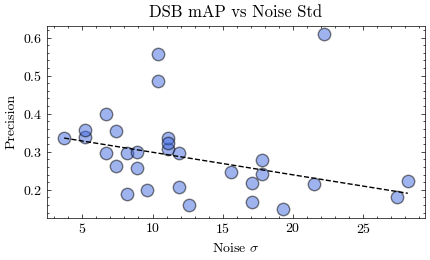

In [45]:
SAVE_PATH_DSB_MAP_NOISE = SAVE_DIR / "dsb_map_vs_noise_nanovision"

results_dsb_map_noise = precision_vs_noise(
    precision=df_stats["dsb_map"],
    noise=df_stats["noise_std"],
    save_path=SAVE_PATH_DSB_MAP_NOISE
)
_retitle_current_figure("DSB mAP vs Noise Std")

results_dsb_map_noise